# Hadron AQC — what this notebook simulates, in plain English

Source circuit: [IBM Quantum tutorial — Loop-String-Hadron dynamics](https://quantum.cloud.ibm.com/docs/en/tutorials/loop-string-hadron-dynamics) (local copy: `tutorials/loop-string-hadron-dynamics.ipynb`).

**The strong force, in miniature.** Inside a proton or neutron, particles called quarks are held together by the strong force. Ordinary computers struggle to simulate how this force makes things change over time. Quantum computers could, in principle, handle it. This tutorial is a proof of concept: simulate a simplified toy version of the strong force and watch it evolve.

**The toy version.** The real strong force has three kinds of charge (called "colours") and acts in 3D space. The toy has two colours and lives on a 1D line of evenly spaced points, each called a **site**. A site is a *place* where particles can appear. It is not itself a particle. The force between particles is best pictured as **strings** running along the links between neighbouring sites. A string can only start or end on a particle, and a longer string costs more energy. So a quark can never be isolated. Pulling a quark away from its partner stretches the string, and eventually the string snaps by creating a new quark–antiquark pair rather than setting a quark free.

**What "gauge" means.** Think of a line of towns (the sites), each with its own **compass**. Every town is free to point its compass however it likes; that choice is pure convention and changes nothing real.
- In this theory the "compass" at each site is the **colour label**. Which colour a site calls "red" or "blue" is an arbitrary choice, made **independently at every site**. That freedom is the **gauge symmetry**.
- Because each town picks its own convention, neighbours can't be compared directly. Every **road between towns (link) must carry a conversion rule**: "to go from this town's compass to that one's, rotate this much." Those conversion rules *are* the force field living on the links. The force exists *because* of this local freedom.
- **SU(2)** is the name for the set of allowed "compass turns" for two colours. Unlike ordinary compass turns, the **order of two turns matters**. That is why the force field affects itself and why strings behave the way they do. (Electricity's version doesn't have this property, which is why ordinary electric field lines don't bind themselves into strings.)
- **What's real and what isn't.** Anything that changes when a town re-points its compass is bookkeeping, not physics. Anything that stays the same no matter how every town points its compass is real. These are called **gauge-invariant**.
- **Gauss's law comes out of this.** For the description to be consistent, field lines can't start or stop in empty space; they must end on charges (quarks). That is where "a string can only end on a particle" comes from.

So the full name of what we simulate is **SU(2) lattice gauge theory in 1D**: a two-colour force (SU(2)), on a grid (lattice), built from the local-freedom principle (gauge).

**Quarks and antiquarks take turns.** This assumption is never written in the code, and the code makes no sense without it. Quarks can only appear on **even**-numbered sites and antiquarks (the antimatter partners of quarks) only on **odd**-numbered sites. Each site has **two slots**, one per colour. On an even site, a filled slot means a quark is there. On an odd site it works backwards: the slots are normally full, and an *empty* slot means an antiquark is there. This is why `get_number` counts differently on odd sites. It uses "filled slots" on even sites and "2 minus filled slots" on odd sites, so both come out as "number of particles actually present".

**The problem with putting the force on qubits.** In its raw form, the force field on each link can take infinitely many values, and a qubit can only hold two. Worse, most of those raw values describe impossible situations, such as strings ending in empty space. So the physics has to be repackaged before it can go on a quantum computer.

**The trick: Loop-String-Hadron (LSH) variables.** Instead of the raw field, each site is described by three whole numbers that automatically obey the string rule:
- **Loop number:** how many strings pass straight *through* the site without ending there. It can be any whole number: 0, 1, 2, and so on.
- **String-in (`n_i`):** 0 or 1. Is there a particle here whose string comes in from the left?
- **String-out (`n_o`):** 0 or 1. Is there a particle here whose string goes out to the right?

These three numbers are **gauge-invariant**: they stay the same no matter how each site labels its colours, so every combination of them is a real, allowed situation. None of the qubit space is wasted on duplicate descriptions or on states that break Gauss's law. This repackaging is exact, so nothing is lost. The strings must also line up: the strings leaving one site to the right must match the strings arriving at the next site.

**What the qubits actually store.** Each qubit is **one slot at one site**: string-in or string-out. A filled or empty slot records whether a particle is there, and the slot's name records which side its string attaches on. A particle is always where a string ends, so the qubits really store the **string ends**, and that is the same as storing the particles. The strings stretched along the links get **no qubits**. Once every string end is known, the strings between them follow automatically, so storing them would be redundant.

**Why 2 qubits per site.** String-in and string-out are each 0 or 1, so each fits on one qubit. That gives **2 qubits per site**: 12 qubits for 6 sites, and 60 for 30. The loop number can be any whole number, so it doesn't fit on a qubit. The tutorial works in a "weak coupling" setting, where the force is weak (the setting `x = 100`; bigger means weaker) and many strings pass through every site. There, the exact loop number barely changes anything, so it's replaced by one average value for the whole lattice. This is an **approximation**, and it only holds when the force is weak.

**The starting state: the "vacuum".** The vacuum is *not* an empty lattice. Even sites are empty and odd sites are full, so there are no quarks, no antiquarks and no strings. It's called the "strong-coupling vacuum" (SCV) because it would be the calmest possible state if the force were infinitely strong. Here the force is weak, so it isn't calm: quark–antiquark pairs start popping out of it on their own. In the 12-qubit simulation, the particle count climbs from 0 to more than 1 per site within 5 steps.

**The meson.** The second starting state is the same vacuum plus a quark at a central even site and an antiquark right next to it, joined by one string. That pair is a **meson**. (Two quarks bound together on a single site is a different object, which LSH calls a hadron. It isn't used here.) Both starting states are run, and the vacuum result is subtracted from the meson result. What's left shows just how the meson spreads, because the vacuum's own pair-popping cancels out. On real hardware, the subtraction also cancels much of the noise the two runs share.

**Moving forward in time: Trotter steps.** The different effects (hopping, string energy, mass) interfere with each other, so you can't jump straight to time *t*. Instead you take many small steps, and each step applies each effect briefly in turn. Each step moves time forward by 0.0015. The three numbers in the code are how much of each effect goes into one step: `c = 0.15` for hopping, `theta = 0.01` for string energy, and `m = 0.03` for mass. The tutorial runs 1 to 10 steps for both starting states, which is **20 circuits** in total. Because the stepping is itself an approximation, the circuit is treated as the "right answer" to compare against. It is not the exact physics.

**What the code builds.** Each step has three physical effects, plus some shuffling:
- **Pair gate:** moves a filled slot to the neighbouring site. Because quarks and antiquarks alternate sites, that one move means either a quark hopping over, or a quark–antiquark pair appearing or disappearing. Hence the name "pair".
- **Electric gate:** the energy of the strings. It acts on the two slots of one site and only adds a *phase*. A phase is a hidden timing shift in the quantum state: it doesn't move any particle, but it changes how later steps combine.
- **Mass rotations:** the energy of having particles at all. These are also phase only.
- **SWAPs:** no physics at all. The qubits sit in a line and only neighbours can interact, so SWAPs shuffle which qubit holds which slot to bring partners together. Each step starts in "zigzag" order (the string-in slots of two neighbouring sites side by side, then their string-out slots) and ends in "paired" order (each site's two slots side by side). Paired order is what `get_number` expects. The very first SWAP layer is skipped because the starting state is already written in zigzag order.

**Reading the result.** Each qubit is measured to get the chance its slot is filled. Those chances turn into a particle count per site. The code reverses the list of results (`evs[::-1]`) because Qiskit numbers qubits from right to left.

**Things to keep in mind.**
- The number of sites must be **even** (6 or 30). The starting-state code only lines up with the zigzag order then.
- This is the **approximate** model (weak force, averaged loop number, stepped time), not the full theory.
- The tutorial's formula for `theta` gives a negative number, but the code uses +0.01. Treat the code's values as the definition.

In [9]:
from typing import Optional
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

### Pair gate — what it is and why the name

**What it does.** It **moves a filled slot to the neighbouring site**. It acts on the *same kind* of slot (both string-in, or both string-out) on two neighbouring sites. If exactly one of the two is filled, the gate lets that occupation hop across: "filled here, empty there" partly turns into "empty here, filled there". If both are empty or both are filled, nothing moves. So the number of filled slots never changes; they only move around.

**How much per step.** The strength is `c = 0.15` per Trotter step. The amount that hops each step is about `sin(c) ≈ 0.15`, i.e. roughly a 2% chance of a move per step. Small steps, repeated many times, add up to real motion.

**Why it matters physically.** This is the gate that makes anything *happen*. Without it, nothing moves and the Electric and Mass gates only add phases to a frozen picture. Because quarks and antiquarks alternate sites (even = quark, odd = antiquark), one move means one of two things:
- a **quark hopping** to a neighbouring site, or
- a **quark–antiquark pair appearing or disappearing**. Moving a filled slot off an odd site leaves an empty slot there (an antiquark), and putting it on an even site creates a quark.

That second case is why the vacuum isn't calm: this gate keeps creating pairs out of it.

**Why "pair Hamiltonian".**
- In standard lattice gauge theory (Kogut–Susskind) this is the **interaction** or **hopping** term: the part of the energy recipe that lets matter move along the links. Its strength is set by `x` (weak force → large `x` → stronger hopping; `c = δτ·x`).
- The tutorial calls it the **"pair"** term because, in the alternating quark/antiquark picture, a move that starts from the vacuum always creates a quark–antiquark pair (and the reverse move destroys one).
- In the full LSH theory this term carries extra factors that depend on the loop number. In the weak-coupling approximation those factors are ≈ 1, which is why it shrinks to this simple two-qubit gate.

**What `XX + YY` means.** It's the standard qubit way of writing "swap an occupation between two slots". The gate is exactly one small time step of that energy (strength `c/2`, checked numerically).

**Naming nuance.** As with the Electric gate, `pair_hamiltonian_circuit` isn't the energy itself; it's **one small time step driven by that energy**.

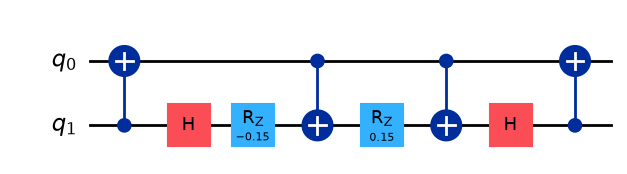

In [10]:
# this couples 2 different sites in the lattice
def pair_hamiltonian_circuit(rzparam: float) -> QuantumCircuit:
    qc = QuantumCircuit(2)
    qc.cx(1, 0)
    qc.h(1)
    qc.rz(-rzparam, 1)
    qc.cx(0,1)
    qc.rz(rzparam, 1)
    qc.cx(0, 1)
    qc.h(1)
    qc.cx(1,0)
    return qc

display(pair_hamiltonian_circuit(rzparam=0.15).draw("mpl"))
# this represents H = XX + YY


### Electric gate — what it is and why the name

**What it does.** It charges energy for the **strings** at one site: it acts on that site's two slots (string-in, string-out) and **only adds a phase**. It never moves a particle, so filled stays filled and empty stays empty. The phase depends on the *pattern* of the two slots (e.g. "one filled, the other empty"), which is why it needs two qubits, not one.

**Why it matters physically.** This is the cost of string. A longer string between a quark and an antiquark costs more energy, and that is **confinement**, the thing that keeps a meson together. In quantum mechanics energy shows up as how fast a state's phase ticks. So this gate makes "long string" arrangements tick differently from "short string" ones. On the next step, the Pair gate's attempts to stretch the string partly cancel out. **The Pair gate proposes moves; the Electric gate's phases decide which moves survive.**

**Why "electric Hamiltonian".**
- **Hamiltonian** = physics jargon for *the recipe for the total energy*. Each way the system can store energy is one term in it.
- Standard lattice gauge theory (the Kogut–Susskind formulation, older than LSH) splits that energy into named terms: **electric** (energy stored in the field along the links, i.e. the strings), **mass** (cost of having particles), and **interaction/hopping** (particles moving or pairs being created; the tutorial calls this the "pair" term). In 2D/3D there is also a "magnetic" term; in 1D it doesn't exist.
- It's called **electric** by analogy with ordinary electricity, where an electric field stores energy. Here it's the *colour*-electric field.
- **LSH doesn't rename these terms.** It keeps the same three and rewrites each one in its own numbers (loop, string-in, string-out).

**Naming nuance.** `electric_hamiltonian_circuit` isn't the energy itself; it's **one small time step driven by that energy** (strength `theta` per step). "Electric time-step gate" would be more precise. The tutorial's name is common shorthand, so we keep it.

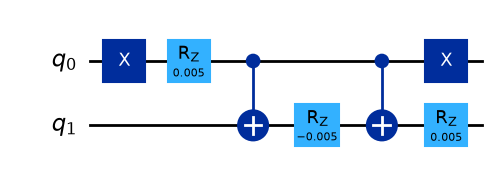

In [11]:
def electric_hamiltonian_circuit(theta: float) -> QuantumCircuit:
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.rz(theta/2, 0)
    qc.cx(0,1)
    qc.rz(-theta/2, 1)
    qc.cx(0,1)
    qc.rz(theta/2, 1)
    qc.x(0)
    return qc

display(electric_hamiltonian_circuit(theta=0.01).draw("mpl"))
# this represents H = -Z0 + Z1 + Z0Z1 (only Z's -> only adds phases, never moves a particle)


### The 1D lattice — the story before the code

Imagine dots on a number line. That's our 1D lattice. Each dot is a **site**.

At each site sits a **box**. The box has two qubits — one for the left slot, one for the right slot. That's all. Two binary switches: 0 (nothing) or 1 (something). The "something" is an energy string — a thread of force connecting two neighbouring sites.

You read the state of the two qubits and the box tells you its story:

| left (n_i) | right (n_o) | what the box is doing |
|:---:|:---:|---|
| 0 | 0 | **empty** — nothing in, nothing out |
| 1 | 1 | **passing through** — string enters from the left, exits unchanged to the right. Nothing is created or destroyed. Also "empty" in that sense. |
| 0 | 1 | **source** — nothing came from the left, but something is going out to the right. This box is generating a string. That is an antiquark. |
| 1 | 0 | **sink** — something came from the left, but nothing exits. This box is absorbing the string. That is a quark. |

A **meson** is a source box and a sink box sitting next to each other, connected by one string. One generates, one absorbs. The string is the bond between them.

---

### The energy recipe (the Hamiltonian)

The total energy of the system has three parts:

```
H  =  H_pair  +  H_electric  +  H_mass
       ↑              ↑             ↑
   kinetic:       field:         rest mass:
   cost of      cost of        cost of a
   a string     having a       particle
   moving       string at all  existing
```

Each part maps directly to one gate we already built:

| term | gate | parameter | what it does |
|---|---|---|---|
| H_pair | `pair_hamiltonian_circuit` | `c = 0.15` | moves a string/quark one step |
| H_electric | `electric_hamiltonian_circuit` | `theta = 0.01` | adds phase for string energy |
| H_mass | alternating `Rz` rotations | `m = 0.03` | adds phase for particle mass |

---

### Why Trotter steps?

To move time forward by one small step δτ, physics says: apply `exp(−i H δτ)` to the state. But H has three parts that interfere with each other — you can't apply them all at once cleanly on a circuit.

**The Trotter trick:** apply each part separately, one after the other, for one small step:

```
one Trotter step ≈  pair gates  →  electric gates  →  mass Rz
                        (H_pair)      (H_electric)     (H_mass)
```

Repeat this `num_trotter_steps` times. Total simulated time = `num_trotter_steps × δτ`.

The approximation is good as long as each step is small. The tutorial uses δτ = 0.0015 and runs 1–10 steps. **`construct_circuit` below assembles exactly this sequence**, plus the SWAP layers that route the right qubits next to each other before each gate layer.

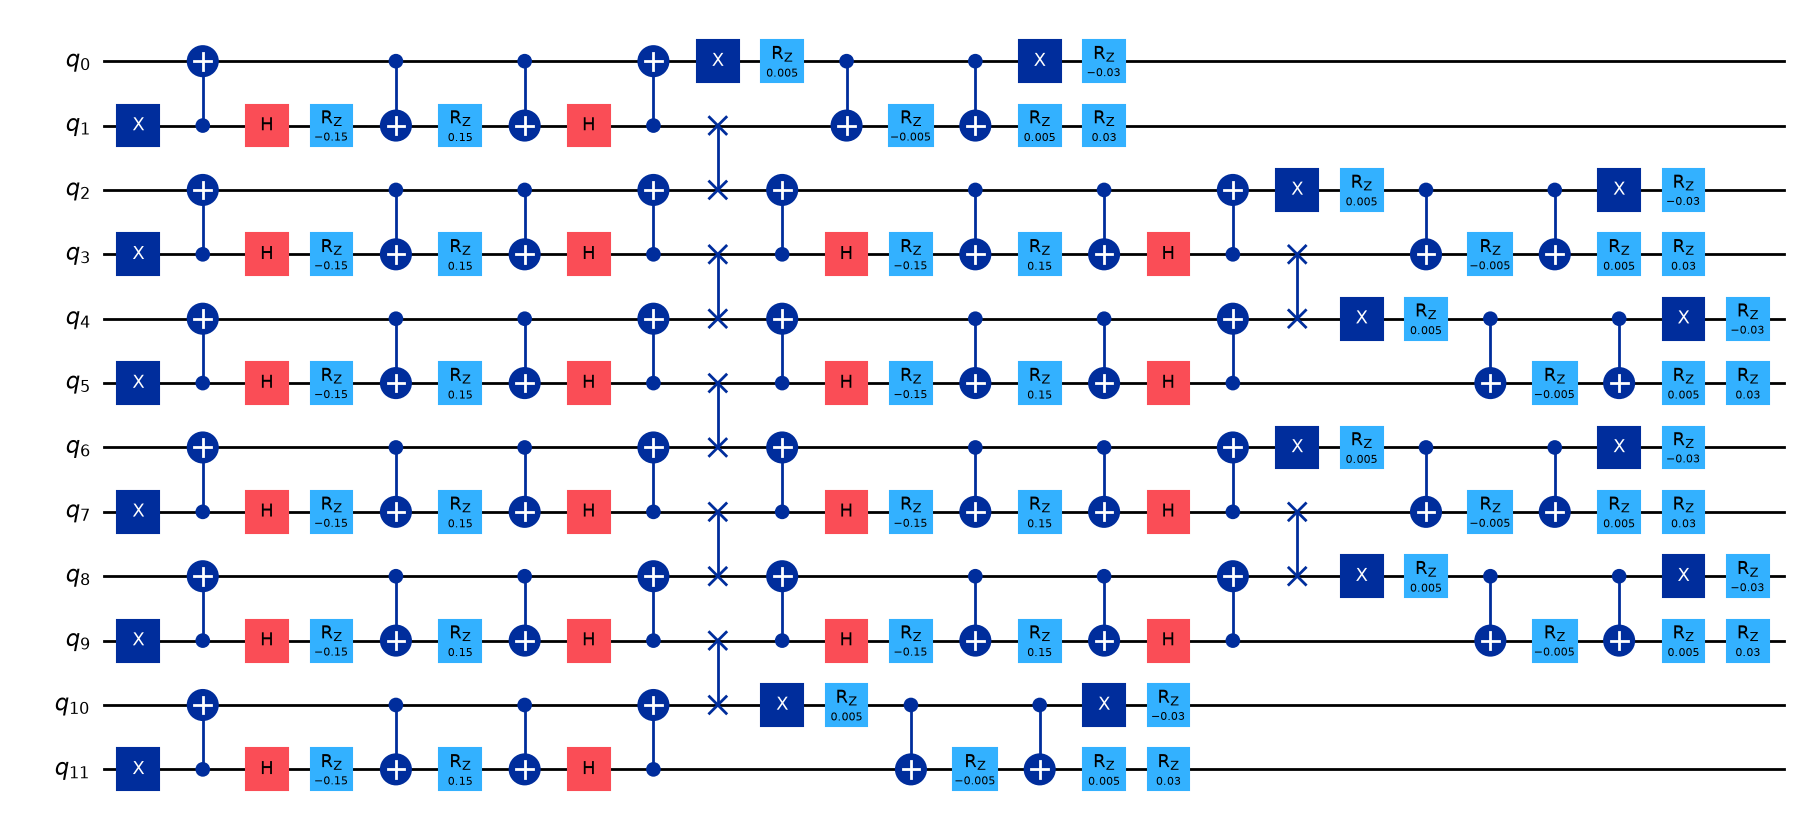

In [12]:
# construct circuit
def construct_circuit(
n_sites,
num_trotter_steps, 
kinetic_strength,
electric_field_strength,
mass, 
qubits_per_site=2,
add_visual_barriers = False,
add_measurements = False,
prep_init_state=True,
use_meson_not_vacuum=False,
):
    num_qubits = qubits_per_site * n_sites
    qc = QuantumCircuit(num_qubits)
    if num_trotter_steps <=0:
        return qc
    # vaccum state Step 1: At even sites we expect quarks. At odd sites we expect antiquarks. The vacuum is the starting state where neither is present yet. To say "quark not present" on an even site, we set it to (0,0). To say "antiquark not present" on an odd site, we set it to (1,1). That's the alternating pattern.
    if prep_init_state:
        i = 1 # represents site 1
        while i < n_sites:
            for j in range(qubits_per_site): #runs 2 times as qubits per site=2
                qc.x(i + j*n_sites) # So it flips pairs (1,7), (3,9), (5,11) 
            i+=2 # jump the pairs.
        if use_meson_not_vacuum:
            center = [num_qubits //2 -1, num_qubits // 2]
            qc.x(center) ## flip center two qubits to inject one meson excitation -> Physical: we want to watch a single quark–antiquark pair born at one spot and see how it spreads over time. Placing it at the center gives it equal room to travel left or right — the evolution comes out symmetric, which makes the heatmap readable. Placing it near an edge would make it bump into the boundary almost immediately.
    else:
        # caller handles state just do swapping
        i=1
        while i < num_qubits-1:
            qc.swap(i, i+1)
            i = i + 4 # not this path is not used at all

    # Trotterization
    for step in range(num_trotter_steps):
        if add_visual_barriers:
            qc.barrier() # draws a visual divider in circuit diagrams, no physics

        # 1. SWAP Layer 1- adjacent qubits at pos 1, 5, 9...
        if step > 0:
            i=1
            while i < num_qubits-1:
                qc.swap(i, i+1)
                i = i + 2*qubits_per_site # step by 4    

        # 2. pair layer 1 - runs EVERY step including step 0
        j = 0
        while j < num_qubits - 2:
            qc.compose(pair_hamiltonian_circuit(kinetic_strength),[j, j+1], inplace=True)
            j = j+2
        if n_sites % 2 == 0:
            qc.compose(pair_hamiltonian_circuit(kinetic_strength),[j, j+1], inplace=True)          
        
        # 3. SWAP layer 2 — crosses n_i and n_o halves together
        i = 1
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + qubits_per_site     # step by 2

        # 4. Pair layer 2 — offset by 2, picks up pairs that layer 1 missed
        j = 2
        while j < num_qubits - 3:
            qc.compose(pair_hamiltonian_circuit(kinetic_strength), [j, j + 1], inplace=True)
            j = j + 2
        if n_sites % 2 != 0:
            qc.compose(pair_hamiltonian_circuit(kinetic_strength), [j, j + 1], inplace=True)

        # 5. SWAP layer 3 — partial undo, restores layout for electric layer
        i = 3
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + 2 * qubits_per_site     # step by 4

        # 6 Electric layer - rotates each site's 2 qubit about Z axis
        if electric_field_strength!=0:
            electric_circ = electric_hamiltonian_circuit(electric_field_strength)
            for j in range(n_sites):
                qc.compose(electric_circ, [2*j, 2*j+1], inplace=True) # place the gate on qubits (0,1), (2,3), (4,5), (6,7), (8,9), (10,11)

        # 7. Mass term — alternating Z-rotations on every qubit (staggered fermion sign)
        for q in range(num_qubits):
            if q % 2 == 0:
                qc.rz(-1 * mass, q)     # even qubits rotate by -m
            else:
                qc.rz(mass, q)          # odd qubits rotate by +m

        # measurements
    if add_measurements:
        qc.measure_all()

    return qc   
     
display(construct_circuit(6, 1, 0.15, 0.01, 0.03).draw("mpl", fold=-1))

### Reading the result — three steps from qubits to physics

Once `construct_circuit` has run, you have a quantum state spread across 12 qubits. Three helper functions turn that into something you can plot.

**Step 1 — `get_probabilities`: what is each qubit showing?**

After the circuit runs, each qubit has a probability of being in state |1⟩ (occupied). This function extracts that — one number per qubit. On a simulator it's exact; on hardware it's estimated from thousands of repeated shots.

**Step 2 — `get_number`: how many particles are at each site?**

Takes the per-qubit probabilities and converts them into the physical particle count `n_f(r)` at each lattice site using the staggered convention:
- Even site: `n_f = n_i + n_o` — add the two slots directly
- Odd site: `n_f = 2 − (n_i + n_o)` — subtract from 2, because at odd sites a filled slot means "nothing here" (the opposite language)

It also reverses the qubit list because Qiskit numbers qubits right-to-left.

**Step 3 — `calculate_difference`: what did the meson actually do?**

Takes `n_f(r)` from the meson run and subtracts `n_f(r)` from the vacuum run, site by site, for each time step. What's left is purely the meson's contribution — the pair-popping the vacuum does on its own cancels out. This difference is what the heatmap plots.

---

In one line: **probabilities → particle counts per site → meson signal**.

In [13]:
#expval = p(|0⟩) - p(|1⟩) eigen values of Z are +1 and -1 corress
#       = (1 - p(|1⟩)) - p(|1⟩)
#       = 1 - 2·p(|1⟩)

# →  p(|1⟩) = (1 - expval) / 2

def get_probabilities(expectationval: float):
    return round((1-expectationval)/2, 3)

# get_physical_particle_count: Z-expectation values → particle count n_f per site per step
#
# num_filled_persite is a number between 0 and 2 (quantum average, not a yes/no):
#   0.0        → no particle at this site
#   1.0        → one particle here (quark or antiquark — see below)
#   2.0        → both slots filled (string passes through, nothing created/destroyed)
#   in between → superposition, value is the expected count
#
# Which kind of particle? The site number tells you — you never need to store it:
#   even site → if something is there, it's a quark
#   odd site  → if something is there, it's an antiquark
#
# Output shape — a list of lists, one row per Trotter step:
#  [
#    [n_f(site 0), n_f(site 1), ..., n_f(site 5)],   ← Trotter step 0
#    [n_f(site 0), n_f(site 1), ..., n_f(site 5)],   ← Trotter step 1
#    ...
#  ]
#  access: all_counts_persite_perstep[step][site]

def get_physical_particle_count(expectation_val_data, n_sites):
    all_counts_persite_perstep = []
    for expectation_val in expectation_val_data:
        probs = [get_probabilities(exp) for exp in expectation_val]
        counts_per_site = []
        for site in range(n_sites):
            occupied_count = probs[2*site] + probs[2*site + 1]
            if site % 2 == 0:
                num_filled_persite = occupied_count          # even site: filled slot = quark present
            else:
                num_filled_persite = 2.0 - occupied_count   # odd site: filled slot = antiquark absent, flip
            counts_per_site.append(num_filled_persite)
        all_counts_persite_perstep.append(counts_per_site)
    return all_counts_persite_perstep

def calc_meson_signal(meson_counts, vacuum_counts, n_sites):
    meson_signal_perstep = []
    for step in range(len(meson_counts)):
        signal_per_site = [abs(meson_counts[step][site]- vacuum_counts[step][site]) for site in range(n_sites)]
        meson_signal_perstep.append(signal_per_site)
    return meson_signal_perstep


In [14]:
# calling code for the hadron circuit using trotterizaton

n_sites = 6
num_qubits = 2*n_sites
trotter_steps = list(range(1, 11))
vacuum_expectation_vals = []
meson_expectation_vals = []

for t_step in trotter_steps:
    for expval, use_meson in [(vacuum_expectation_vals, False), (meson_expectation_vals, True)]:
        state_vector = Statevector(construct_circuit(n_sites, t_step, 0.15, 0.01, 0.03, use_meson_not_vacuum=use_meson))
        expectation_val = [state_vector.expectation_value(SparsePauliOp('I'*q + 'Z' + 'I'*(num_qubits-q-1))).real for q in range(num_qubits)][::-1]
        expval.append(expectation_val)

vacuum_counts = get_physical_particle_count(vacuum_expectation_vals, n_sites)
meson_counts = get_physical_particle_count(meson_expectation_vals, n_sites)
meson_signal = calc_meson_signal(meson_counts, vacuum_counts, n_sites)

import numpy as np
print("meson step 1:", [round(x,3) for x in meson_counts[0]])
print("vacuum step 1:", [round(x,3) for x in vacuum_counts[0]])
print("signal step 1:", [round(x,3) for x in meson_signal[0]])


meson step 1: [np.float64(0.044), np.float64(0.066), np.float64(1.022), np.float64(1.022), np.float64(0.066), np.float64(0.044)]
vacuum step 1: [np.float64(0.044), np.float64(0.088), np.float64(0.088), np.float64(0.088), np.float64(0.088), np.float64(0.044)]
signal step 1: [np.float64(0.0), np.float64(0.022), np.float64(0.934), np.float64(0.934), np.float64(0.022), np.float64(0.0)]


### Plotting the result — watching the meson spread

We plot three heatmaps side by side:

- **X-axis** — lattice site (0 to 5, left to right)
- **Y-axis** — Trotter step (1 to 10, bottom to top = forward in time)
- **Colour** — particle count `n_f` at that site at that time. Brighter = more particles.

**Left panel — Meson:** particle count when the simulation starts with a meson at the center. You should see a bright spot at sites 2–3 at the bottom, spreading outward as time moves up.

**Middle panel — Vacuum:** particle count when the simulation starts with just the empty vacuum. The vacuum itself generates pairs over time, so this panel shows background noise that has nothing to do with the meson.

**Right panel — Signal `|meson − vacuum|`:** the difference between the two. The vacuum's pair-popping cancels out and what's left is purely the meson's contribution. This is the physics result: the meson's signal propagating across the lattice.

```
imshow(data, origin="lower")  — origin="lower" puts step 1 at the bottom (early time),
                                 step 10 at the top (late time), which reads naturally
extent=[0, n_sites, 0.5, 10.5]  — maps pixel coordinates to site numbers and step numbers
```

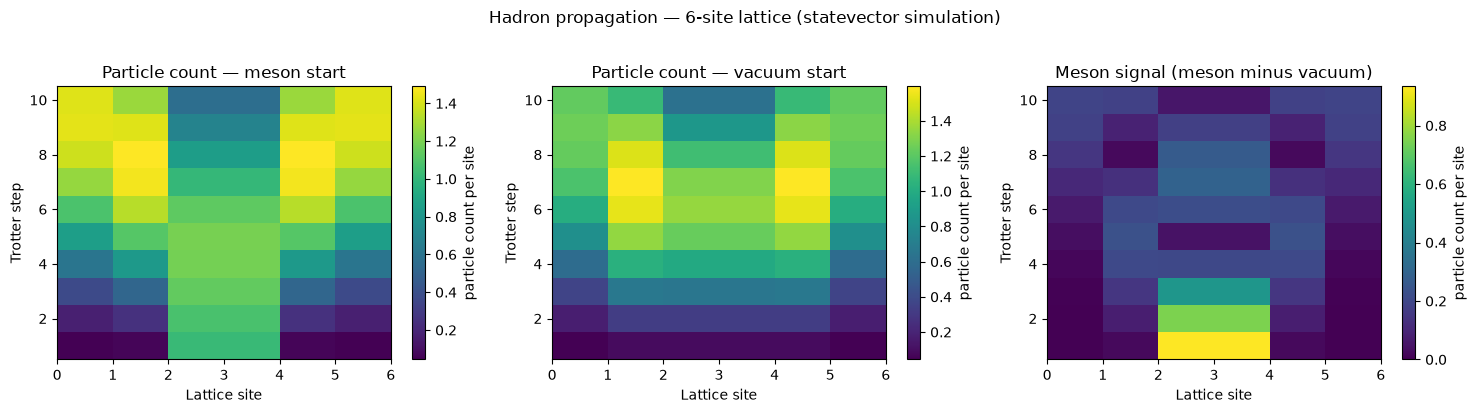

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

panels = [
    (meson_counts,  "Particle count — meson start"),
    (vacuum_counts, "Particle count — vacuum start"),
    (meson_signal,  "Meson signal (meson minus vacuum)"),
]

for ax, (data, title) in zip(axes, panels):
    im = ax.imshow(
        np.array(data, dtype=float),
        aspect="auto",
        origin="lower",
        extent=[0, n_sites, 0.5, len(trotter_steps) + 0.5],
    )
    ax.set_xlabel("Lattice site")
    ax.set_ylabel("Trotter step")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="particle count per site")

plt.suptitle("Hadron propagation — 6-site lattice (statevector simulation)", y=1.02)
plt.tight_layout()
plt.show()

### Reading the result — right panel only ("Meson signal")

**How to read the axes.** Each coloured box is one site at one Trotter step. Site 0 fills the box between 0 and 1 on the x-axis, site 1 fills 1–2, and so on. So the two middle boxes between **2 and 4** on the x-axis are **sites 2 and 3**, where we placed the meson. Colour = how much `meson_counts` differs from `vacuum_counts` at that box: **yellow = big difference, dark violet = almost no difference**.

---

**The middle column (sites 2–3) — follow it bottom to top:**

| Trotter step | colour you see | `meson_signal` value |
|:---:|---|:---:|
| 1 | yellow | 0.93 |
| 2 | light green | 0.75 |
| 3 | teal | 0.49 |
| 4 | light violet | 0.20 |
| 5 | **dark violet** | 0.04 |
| 6 | light violet | 0.22 |
| 7 | lighter violet, close to teal | 0.29 |
| 8 | light violet | 0.27 |
| 9 | violet | 0.18 |
| 10 | **dark violet** | 0.06 |

**What happens:** the meson starts at full strength in the middle (yellow). Over steps 1–5 it drains out, until at step 5 the middle looks almost exactly like the vacuum (dark violet). Then it **comes back** — steps 6–8 get brighter again. Then it drains out a second time, and by step 10 it is dark violet again.

**Where does it go when the middle goes dark?** Look at the columns right next to it — **sites 1 and 4** (x-axis 1–2 and 4–5). They do the opposite of the middle:

- steps 1–5: they slowly brighten, peaking at step 5 (0.23) — exactly when the middle is darkest
- step 8: they drop to almost nothing (0.02) — exactly when the middle has come back
- steps 9–10: they brighten again (0.18) as the middle darkens again

**The far edges — sites 0 and 5** (x-axis 0–1 and 5–6) stay dark for most of the run and only turn a faint violet near the top (0.19 at step 10). Only a little of the meson's effect reaches the ends.

---

**In plain words:** the meson does not simply spread out and leave. It **sloshes back and forth** — out of the middle into its neighbours (steps 1–5), back into the middle (steps 6–8), and out again (steps 9–10). Each time, a little more leaks further out toward the edges.

**One caution about "dark".** The panel shows the *size* of the difference between the meson run and the vacuum run, not how many particles are there. Dark violet means "the meson run and the vacuum run look the same here", not "this site is empty".

### Reading the left and middle panels

**What the colour means here.** Unlike the right panel, these two show the actual **particle count per site**: `meson_counts` on the left, `vacuum_counts` in the middle. Each value runs from 0 to 2:
- **0 (dark violet)** means nothing at this site
- **about 1 (teal/green)** means roughly one particle here
- **about 1.5 (yellow)** means the site is well filled

On even sites the particle is a quark, and on odd sites it's an antiquark.

**Careful:** each panel has its **own colour bar**. Yellow on the left is about 1.49, and yellow in the middle is about 1.6. Compare colours *within* a panel, not across panels.

**Note:** the bottom row is Trotter step 1, not the starting state. One step has already run, so nothing is exactly 0.

---

#### Middle panel — vacuum start

We start with **no particles anywhere**. Follow the columns bottom to top:

| sites | x-axis | bottom (step 1) | peak | top (step 10) |
|---|---|---|---|---|
| 2, 3 (middle) | 2–4 | dark violet, 0.09 | light green, 1.35 at step 6 | teal, 0.63 |
| 1, 4 | 1–2, 4–5 | dark violet, 0.09 | **yellow, 1.60 at step 7** | green, 1.09 |
| 0, 5 (edges) | 0–1, 5–6 | dark violet, 0.04 | green, 1.25 at step 9 | green, 1.23 |

**What happens:** the empty vacuum doesn't stay empty. The pair gate keeps creating quark–antiquark pairs out of nothing, so every column brightens as you go up. Sites 1 and 4 fill up fastest and turn yellow. The edge sites fill up slowest because they have only one neighbour to exchange with, not two. After about step 7, the middle columns start fading again: some of the pairs are being destroyed as well as created. So the vacuum rises and then falls back.

**Why this panel matters:** it's the **background**. The vacuum does all of this by itself, with or without a meson.

---

#### Left panel — meson start

Same vacuum, plus one meson placed at sites 2 and 3: a quark on site 2 and an antiquark on site 3.

| sites | x-axis | bottom (step 1) | middle of run | top (step 10) |
|---|---|---|---|---|
| 2, 3 (middle) | 2–4 | **green, 1.02** | light green, 1.19 at steps 4–5 | teal/blue, 0.57 |
| 1, 4 | 1–2, 4–5 | dark violet, 0.07 | **yellow, 1.49 at step 8** | yellow-green, 1.27 |
| 0, 5 (edges) | 0–1, 5–6 | dark violet, 0.04 | teal, 0.85 at step 5 | **yellow, 1.42** |

**What happens:**
- **Middle column (sites 2–3):** it starts green, not dark. That's the meson: about one particle on each of the two sites from the very first step. It stays roughly steady, around 1.0–1.2, until step 6, then fades to teal/blue by the top.
- **Sites 1 and 4 and the edges:** they start dark and brighten steadily, just like in the vacuum panel. Sites 1 and 4 are brightest at step 8, and the edges keep brightening all the way to the top.

---

#### Why the left and middle panels look so alike

Both panels are dominated by the same thing: the vacuum creating pairs everywhere. The meson is only a small extra on top of that background. It's clearest at the very bottom of the middle column, green on the left and dark violet in the middle.

Subtracting the middle from the left removes the shared background. What's left is the right panel, which shows only what the meson did.